In [ ]:
import torch

from tqdm import tqdm
import warnings

from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
import glob
import os
from collections import OrderedDict 
 
import numpy as np
import matplotlib.pyplot as plt  

import pandas as pd 


In [ ]:
import yaml
import numpy as np
from src.data.modules.LitData  import LitData

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
DICT = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
    }
def produce_report(path_1):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
   
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = ATATClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            
            od_atat[key.replace("atat.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        #print(b1['mask'].sum(dim = [1,2])[0])
        lc_emb,f_emb,mix = model(**b1)  
        lc_emb = mix
        t = b1['labels']
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    print(classification)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    from src.utils.plottinglib import elasticc_confusion_matrix
    out_metrics_balto = classification_report(
        target, results, target_names=list(DICT.keys()), output_dict=True
    )["macro avg"]
    template_balto = ""
    for key in out_metrics_balto.keys():
        template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
    fig, axes = plt.subplots(1, 1, figsize=(12, 12))
    elasticc_confusion_matrix(
        y_true=np.array(target).astype(int),
        y_pred=np.array(results).astype(int),
        classes= np.array(list(DICT.keys())),
        ax=axes,
        normalize=True,
        title=f" FClassifier Results [TEST] \n\n {template_balto}",
    )
    plt.show()
    return data_dict

ModuleNotFoundError: No module named 'src.layers.selfsupervised'

In [ ]:
path_1  = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC_MD/ATAT_baseline_33_0/'
path_2 = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/TESTDROPOUT_v01_0/'

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata True 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.58it/s]


                precision    recall  f1-score   support

           AGN     0.7898    0.7494    0.7691      3935
           QSO     0.8115    0.8320    0.8216      4108
            EA     0.8248    0.7799    0.8017      4352
           YSO     0.8159    0.8112    0.8136      3295
          SNIa     0.6617    0.6368    0.6490      2175
       CV/Nova     0.8089    0.7361    0.7708      1944
          RRLc     0.7787    0.7563    0.7673      4243
         RSCVn     0.7586    0.8156    0.7861      3124
        Blazar     0.7187    0.8057    0.7597      1709
          SNII     0.4227    0.4183    0.4205      1040
         EB/EW     0.7347    0.7651    0.7496      4615
           LPV     0.9566    0.9011    0.9280      4135
           CEP     0.7997    0.7001    0.7466      3508
         RRLab     0.7361    0.8123    0.7724      4423
Periodic-Other     0.5233    0.6419    0.5766       874
          DSCT     0.5983    0.6634    0.6292      2059
         SNIbc     0.2217    0.2513    0.2356  

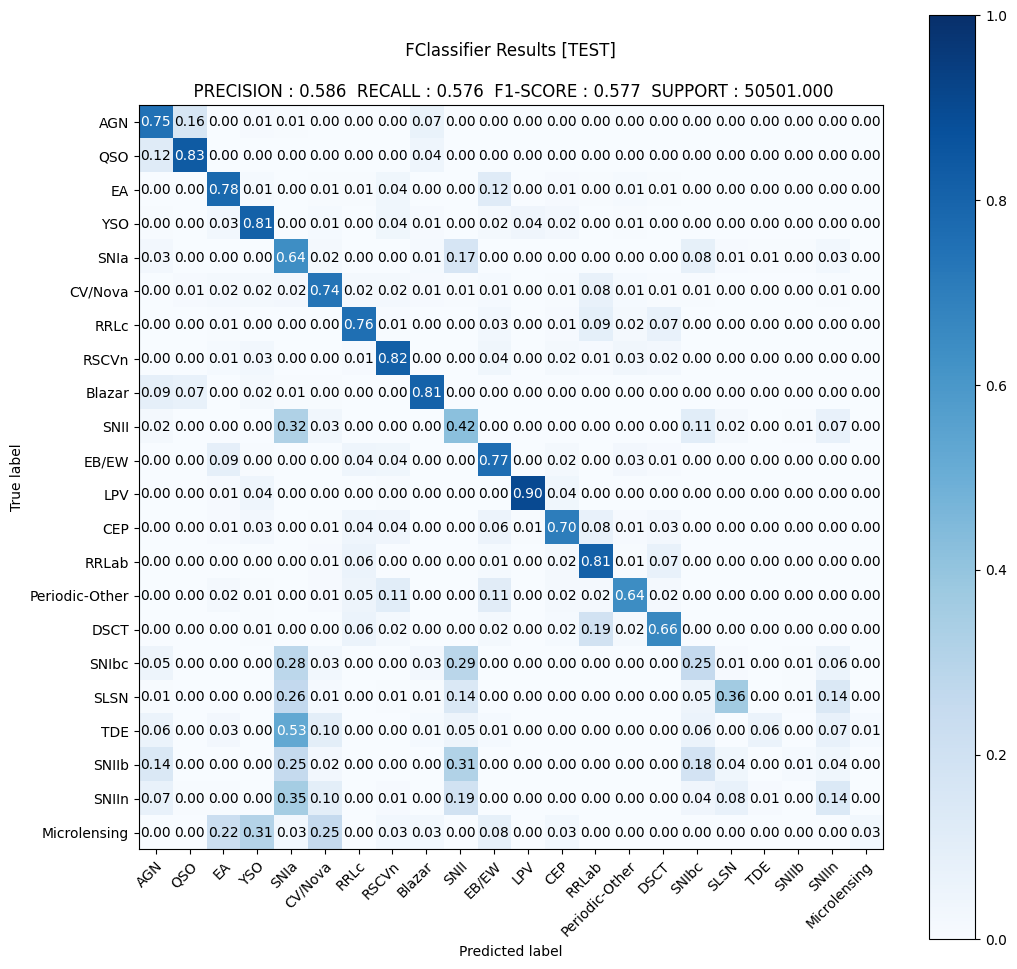

In [ ]:
data_dict_1 = produce_report(path_1)

In [ ]:
preds_val, target_val = test._predict(test._init_dataloader(test.path_to_dataset, set_type = 'validation'), "LC")
import pandas as pd
import matplotlib.pyplot as plt
preds_val_df = pd.DataFrame(preds_val)
preds_val_df = pd.concat([preds_val_df,pd.DataFrame({'target': target_val})],axis = 1)


display(preds_val_df)
fig = plt.figure(figsize = (24,10))
ax = fig.add_subplot(111)
for i in range(22):
    sns.scatterplot(preds_val_df.query('target == {}'.format(i)).mean(axis  = 0).drop('target'),ax = ax )
plt.grid()

ModuleList(
  (0-1): 2 x Dendro(
    (linear_r): Linear(in_features=4, out_features=128, bias=False)
    (dropout): Dropout(p=0, inplace=False)
  )
)
using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:16<00:00, 11.78it/s]


                precision    recall  f1-score   support

           AGN     0.4510    0.2734    0.3405      3935
           QSO     0.5673    0.5426    0.5547      4108
            EA     0.7665    0.7233    0.7443      4352
           YSO     0.4753    0.5511    0.5104      3295
          SNIa     0.3892    0.1623    0.2291      2175
       CV/Nova     0.4746    0.4378    0.4554      1944
          RRLc     0.8124    0.5899    0.6835      4243
         RSCVn     0.5266    0.5221    0.5244      3124
        Blazar     0.2811    0.2961    0.2884      1709
          SNII     0.2419    0.2212    0.2310      1040
         EB/EW     0.6994    0.6535    0.6757      4615
           LPV     0.7951    0.6447    0.7121      4135
           CEP     0.6015    0.4914    0.5409      3508
         RRLab     0.7130    0.5853    0.6429      4423
Periodic-Other     0.1974    0.5835    0.2950       874
          DSCT     0.3435    0.5823    0.4321      2059
         SNIbc     0.0822    0.2915    0.1282  

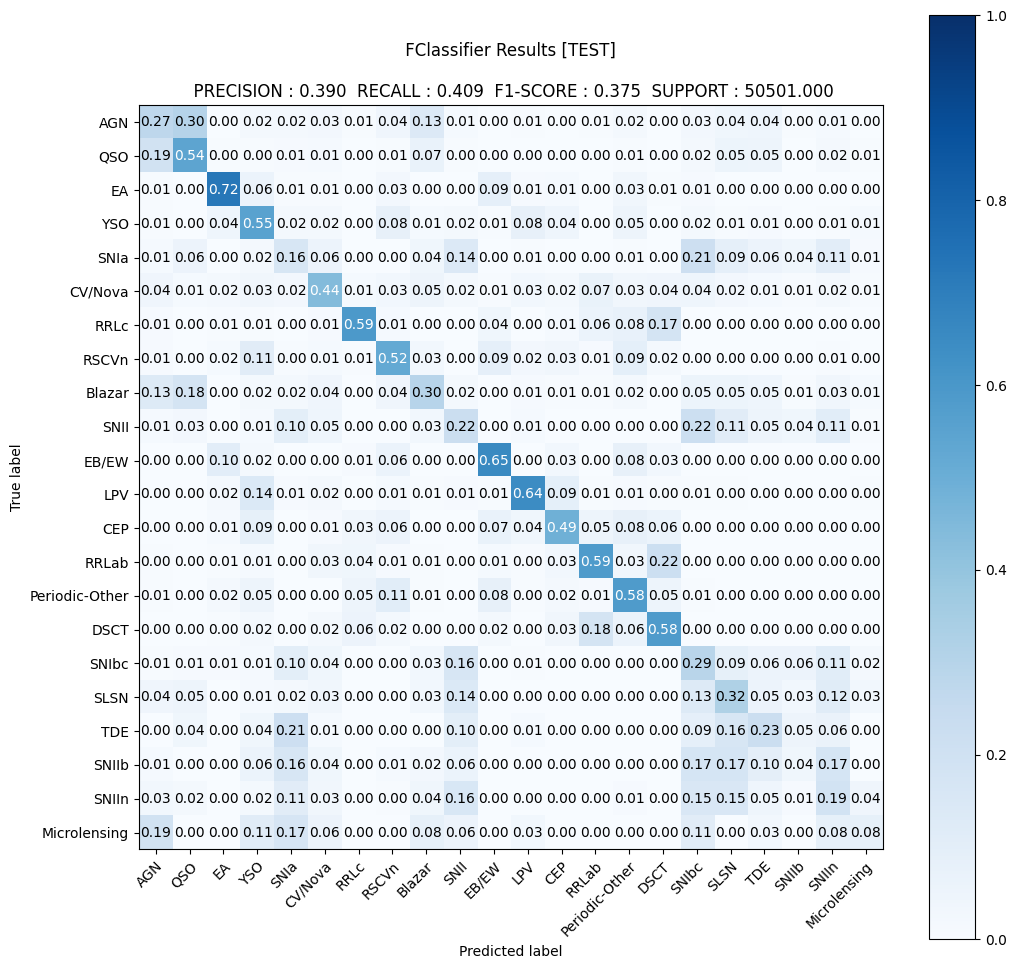

In [ ]:
data_dict_2 = produce_report(path_2)

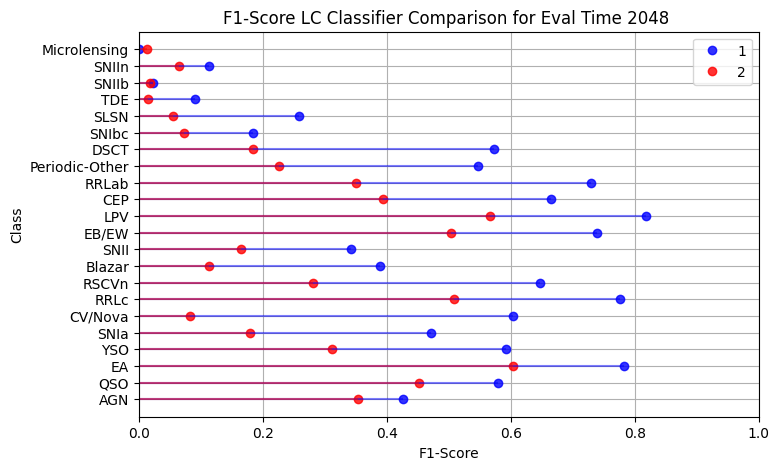

In [ ]:
import pandas as pd
import numpy as np
def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in d1.items():
        print(key,value)
        if key in ZTF_TAXONOMY().keys():
        
            f1_baseline.append(value['f1-score'])
        
    df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
    ordered_df_1 = df_1 #.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)

    for key,value in d2.items():
        if key in (ZTF_TAXONOMY().keys()):
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_finetune})
    ordered_df_2 = df_2 #.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(-0.01,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )

    plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})',
                f'pretrained (macro: {np.round(d2['macro avg']['f1-score'],4)} | accuracy:  {np.round(d2['accuracy'],4)})'])
    # Show the plot
    plt.show()
compare_models(report_1,report_2)

In [ ]:
transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}
periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}

In [ ]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict_1.items():
    #print(class_key)
    if class_key in DICT.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))

print('per',np.mean(per_f1))


group eval:
trans 0.18525274603364555
stoch 0.5179515533066692
per 0.6976197112649278


In [ ]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict_2.items():
    #print(class_key)
    if class_key in DICT.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')    
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

group eval:
trans 0.07266030556066241
stoch 0.2627087668460834
per 0.40173568612375743


In [ ]:
adfadf

NameError: name 'adfadf' is not defined

In [ ]:
def early_as(path_1:str, before_time:int,supress_cm = False,supress_dict = False):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        #print(b1['time'].shape,b1['mask'].shape)
        b1['data'][:,before_time:,:] = 0
        b1['time'][:,before_time:,:] = 0
        b1['mask'] = (b1['data'] !=0)
        #mask = torch.ones_like(b1['mask'])
        #mask[before_time:,:] = 0 
        #b1['mask'] = b1['mask'] * mask
        lc_emb = model(**b1)  
        t = b1['labels']
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    if supress_dict == 0:
        print(classification)
    if supress_cm == 0:        
        from src.utils.plottinglib import elasticc_confusion_matrix
        out_metrics_balto = classification_report(
            target, results, target_names=list(DICT.keys()), output_dict=True
        )["macro avg"]
        template_balto = ""
        for key in out_metrics_balto.keys():
            template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
        fig, axes = plt.subplots(1, 1, figsize=(12, 12))
        elasticc_confusion_matrix(
            y_true=np.array(target).astype(int),
            y_pred=np.array(results).astype(int),
            classes= np.array(list(DICT.keys())),
            ax=axes,
            normalize=True,
            
            title=f" FClassifier Results [TEST] \n\n {template_balto}",
        )
        plt.show()
    
    return data_dict

In [ ]:
data_dict_1['macro avg']['f1-score']

0.47103602810632705

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:16<00:00, 11.72it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.62it/s]


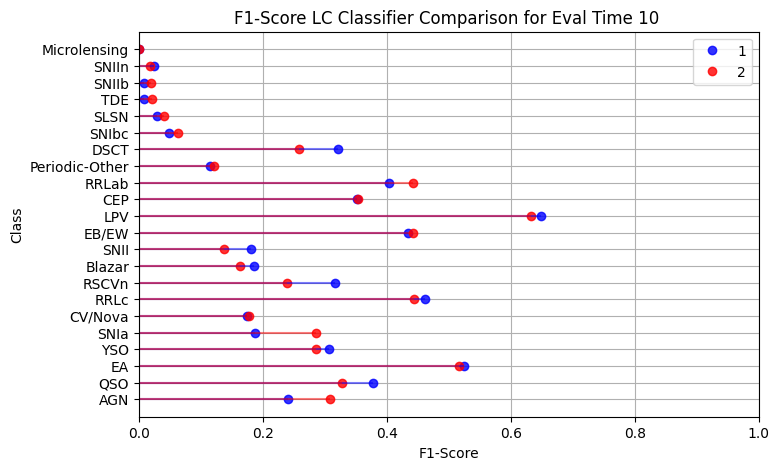

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.54it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.53it/s]


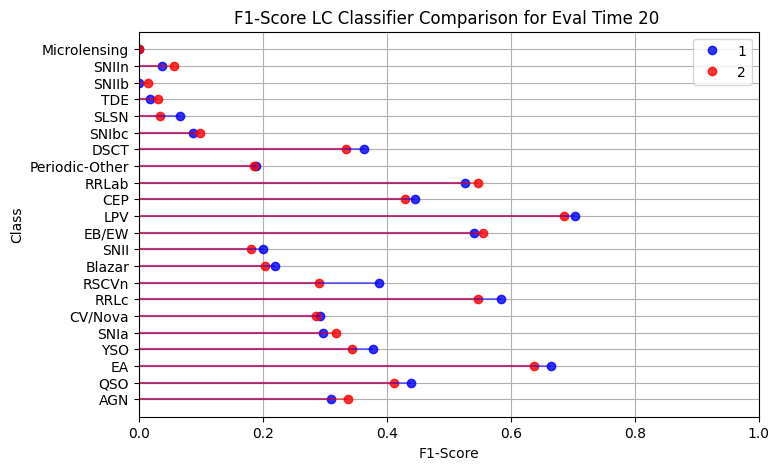

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.51it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


 50%|█████     | 99/198 [00:08<00:08, 11.62it/s]

100%|██████████| 198/198 [00:17<00:00, 11.47it/s]


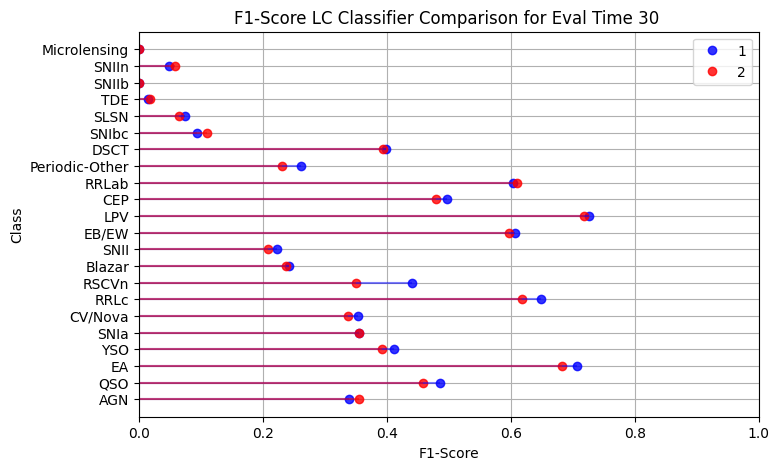

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.43it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.41it/s]


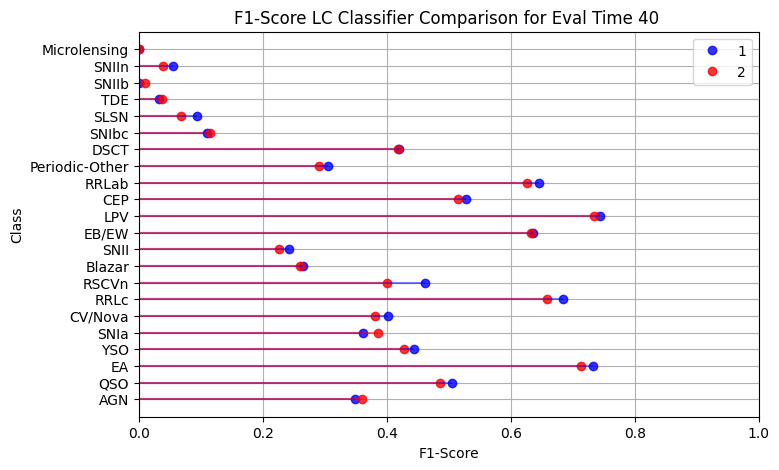

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.41it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.38it/s]


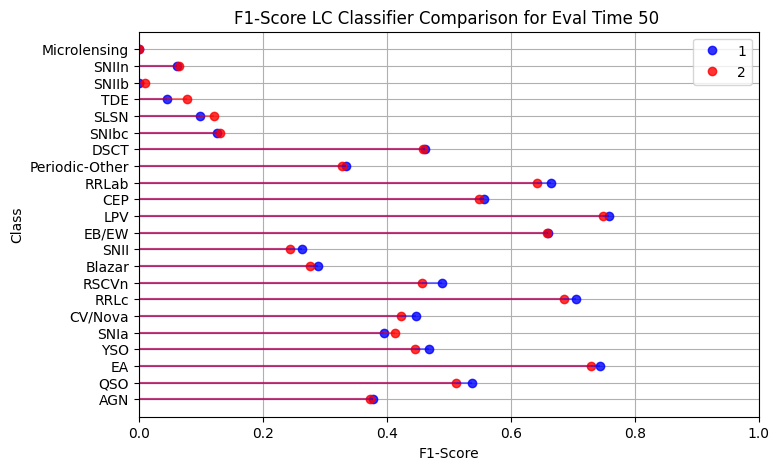

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.40it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.36it/s]


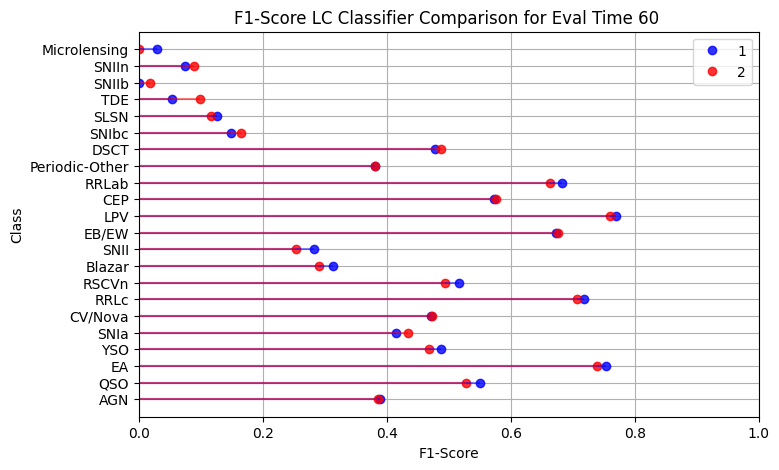

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.35it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.34it/s]


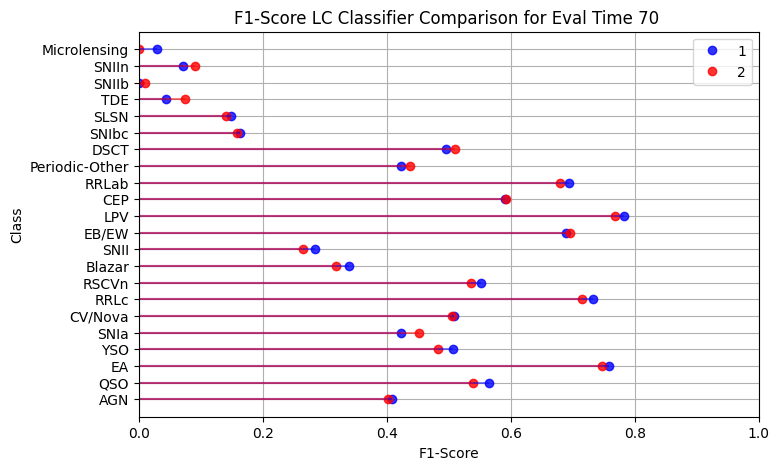

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.35it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.34it/s]


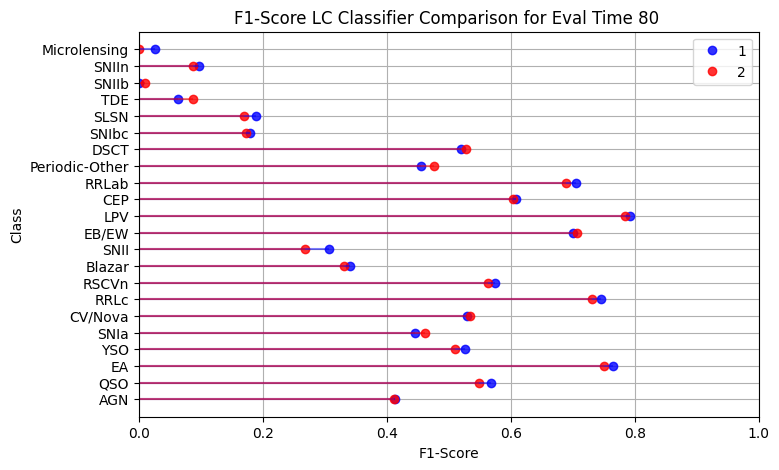

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.33it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.30it/s]


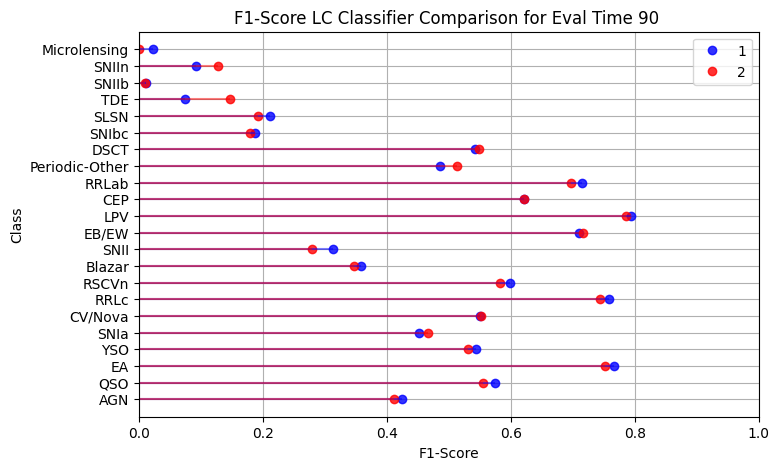

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.33it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.31it/s]


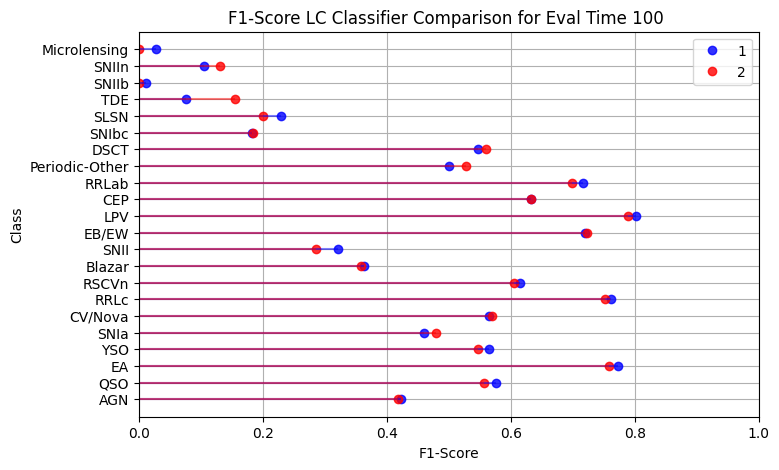

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.33it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.32it/s]


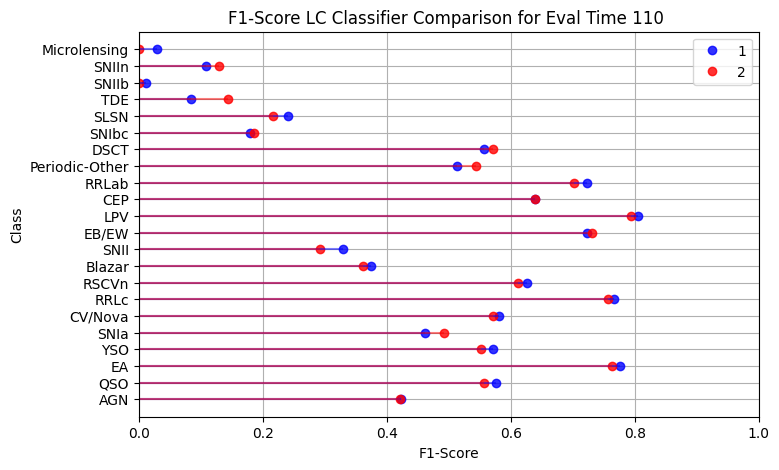

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.07it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.29it/s]


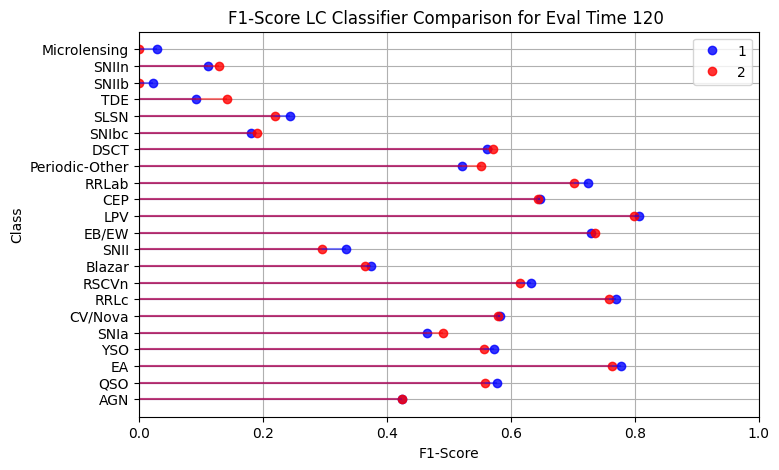

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.34it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.32it/s]


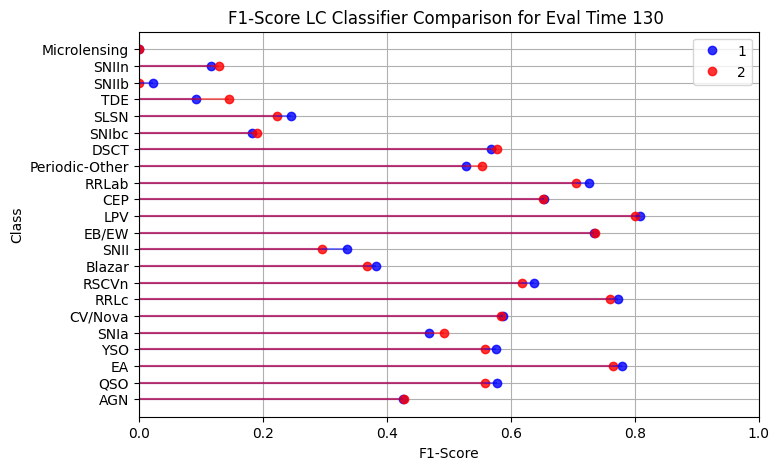

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.29it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.31it/s]


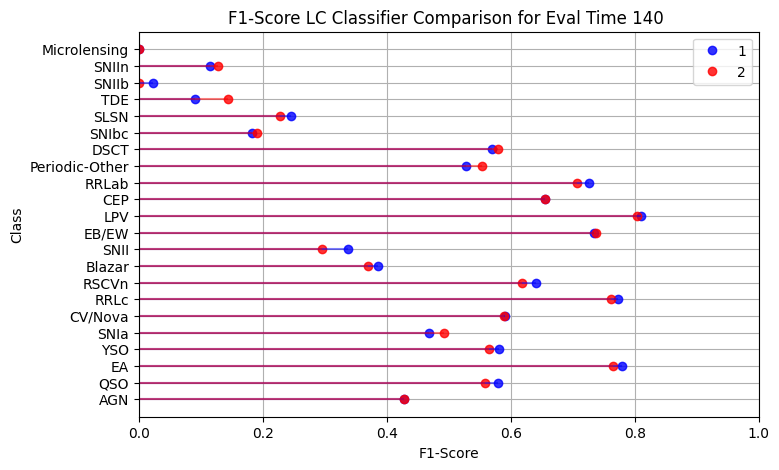

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.33it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.29it/s]


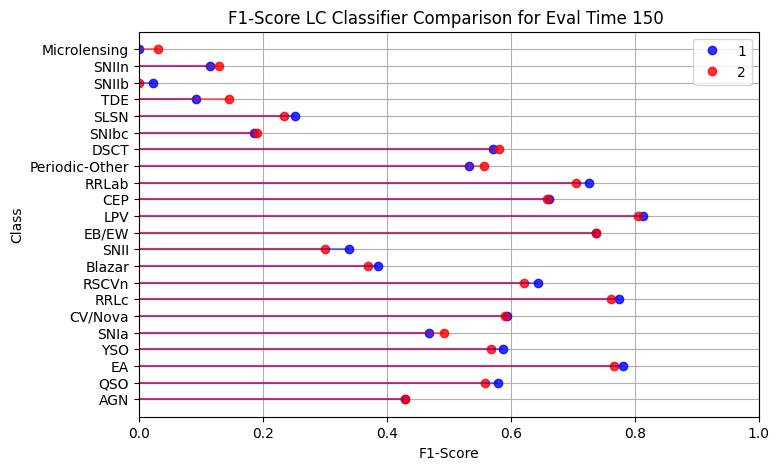

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.32it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.29it/s]


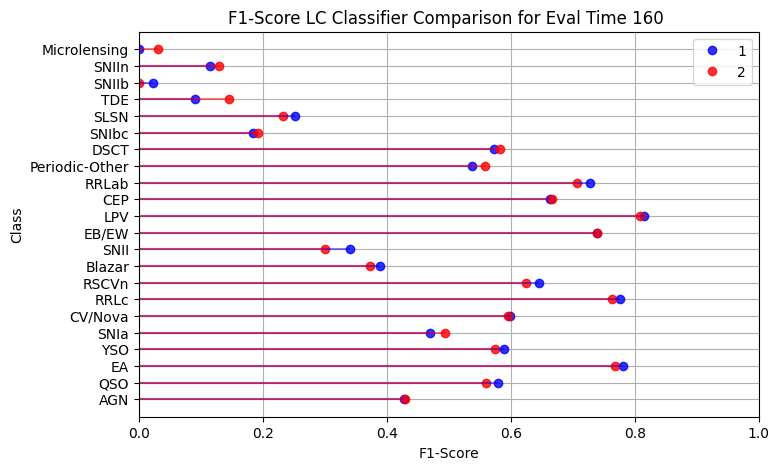

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.31it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.27it/s]


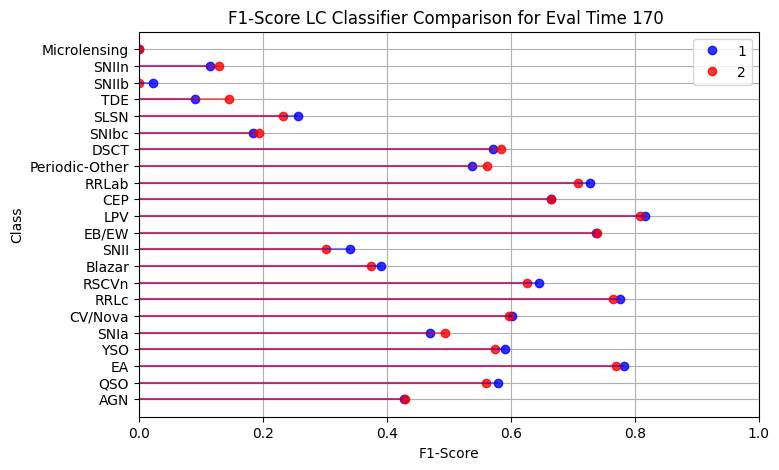

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.32it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.33it/s]


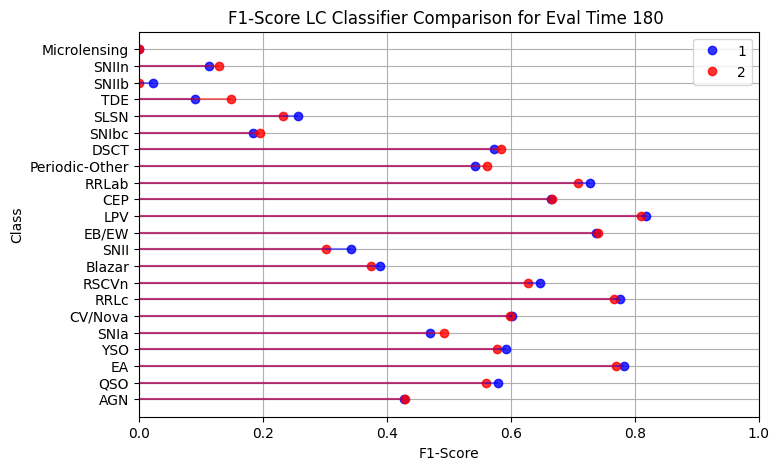

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.31it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:17<00:00, 11.29it/s]


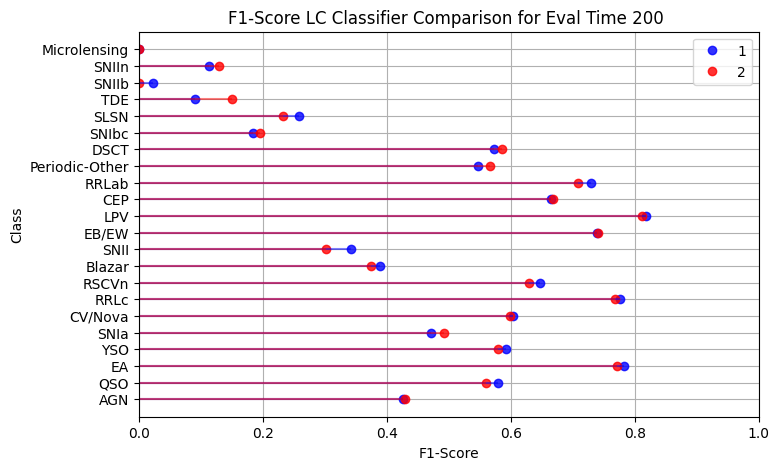

using set validation total of idx : 40698 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type validation
NOT USING SAMPLER FOR DATASET validation


100%|██████████| 159/159 [00:14<00:00, 11.26it/s]


                precision    recall  f1-score   support

           AGN     0.4875    0.4109    0.4459      3288
           QSO     0.5840    0.5747    0.5793      3428
            EA     0.8140    0.7577    0.7848      3500
           YSO     0.5817    0.6147    0.5978      2715
          SNIa     0.4759    0.4582    0.4669      1639
       CV/Nova     0.6463    0.5900    0.6169      1617
          RRLc     0.7792    0.7397    0.7589      3439
         RSCVn     0.5694    0.6507    0.6073      2522
        Blazar     0.3377    0.4362    0.3807      1364
          SNII     0.3067    0.4252    0.3563       802
         EB/EW     0.7228    0.7023    0.7124      3635
           LPV     0.8391    0.8075    0.8230      3319
           CEP     0.6964    0.6559    0.6755      2871
         RRLab     0.8045    0.6701    0.7312      3507
Periodic-Other     0.5186    0.6186    0.5642       742
          DSCT     0.5083    0.6696    0.5779      1604
         SNIbc     0.1729    0.2364    0.1997  

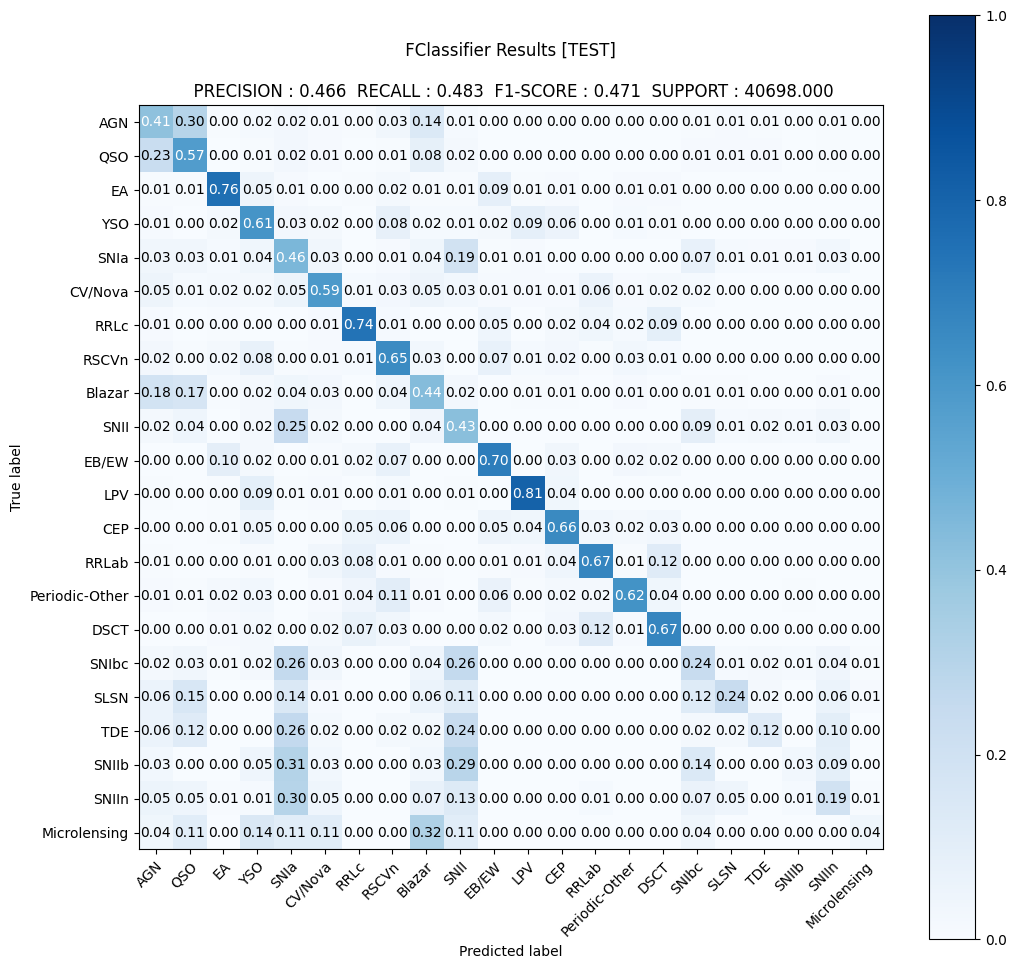

using set validation total of idx : 40698 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type validation
NOT USING SAMPLER FOR DATASET validation


100%|██████████| 159/159 [00:14<00:00, 11.23it/s]


                precision    recall  f1-score   support

           AGN     0.4820    0.4203    0.4491      3288
           QSO     0.5934    0.5292    0.5594      3428
            EA     0.8171    0.7251    0.7684      3500
           YSO     0.5848    0.6221    0.6029      2715
          SNIa     0.4625    0.5235    0.4911      1639
       CV/Nova     0.6290    0.6017    0.6150      1617
          RRLc     0.7784    0.7159    0.7458      3439
         RSCVn     0.6210    0.5852    0.6026      2522
        Blazar     0.2982    0.4751    0.3664      1364
          SNII     0.3499    0.3953    0.3712       802
         EB/EW     0.7011    0.7227    0.7117      3635
           LPV     0.8413    0.8084    0.8245      3319
           CEP     0.6801    0.6722    0.6761      2871
         RRLab     0.7558    0.6424    0.6945      3507
Periodic-Other     0.4923    0.6496    0.5601       742
          DSCT     0.4845    0.7120    0.5766      1604
         SNIbc     0.2500    0.2141    0.2306  

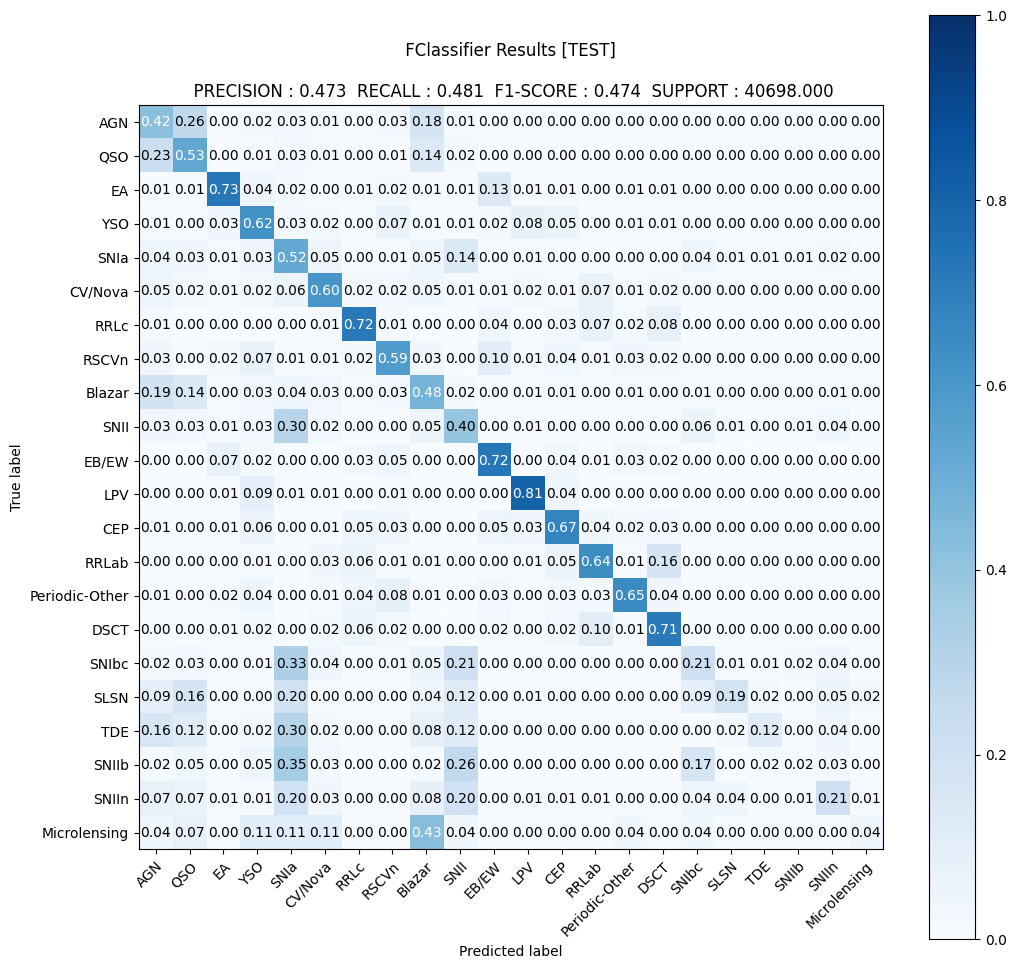

In [ ]:
e_times = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,200]
macro_f1_eval_times = {'d1':[],'d2':[]}
for eval_time in e_times:
    data_dict_1 = early_as(path_1, before_time = eval_time,supress_cm=True,supress_dict=True)
    data_dict_2 = early_as(path_2, before_time = eval_time,supress_cm=True,supress_dict=True)
    macro_f1_eval_times['d1'].append(data_dict_1['macro avg']['f1-score'])
    macro_f1_eval_times['d2'].append(data_dict_2['macro avg']['f1-score'])
    compare_models(data_dict_1,data_dict_2,eval_time)

data_dict_1 = produce_report(path_1)
data_dict_2 = produce_report(path_2) 

In [ ]:
import seaborn as sns

sns.lineplot(macro_f1_eval_times[::-1])
#plt.legend(['baseline','pretrained'])

plt.title('F1-score for ')
plt.xticks(list(range(len(e_times))),[str(time) for time in e_times])
plt.xlabel('Max Evaluated Time')
plt.ylabel('F1-score')
plt.grid('on')

KeyError: slice(None, None, -1)

modl is not sample dependent